In [481]:
import os
import pandas as pd

In [482]:
df_merged = pd.read_csv('./df_merged.csv')
df_match = pd.read_csv('./df_match.csv')

In [483]:
df_match.shape, df_merged.shape

((234961, 7), (807, 15))

In [484]:
df_merged.columns

Index(['ouid', 'grade_ranking', 'season_grade_ranking', 'recent_win_rate',
       'recent_kill_death_rate', 'recent_assault_rate', 'recent_sniper_rate',
       'recent_special_rate', 'solo_rank_match_tier', 'solo_rank_match_score',
       'party_rank_match_tier', 'party_rank_match_score', 'user_date_create',
       'manner_score', 'clan_flag'],
      dtype='object')

In [485]:
df_match.columns

Index(['match_id', 'date_match', 'match_result', 'kill', 'death', 'assist',
       'ouid'],
      dtype='object')

### Match Data Engineering

#### 목적  
- `df_match` 데이터에서 `match_id` 기준이 아닌 `ouid` 기준으로 데이터를 재구성하여,  
  **유저별 최근 전투 기록 및 성능 지표**를 계산하고 이를 분석 및 모델 학습에 활용할 수 있는 형태로 정리함.

#### 주요 작업  
- `ouid`를 기준으로 유저별 전체 매치 데이터를 그룹화하고, 다음과 같은 전투 지표를 생성함:
  - 총 매치 수 (`total_matches`)
  - 승/무/패 횟수 (`is_win`, `is_draw`, `is_loss`)
  - 실제 승률 (`actual_win_rate`)
  - 총 킬/데스/어시스트 수 (`user_kill`, `user_death`, `user_assist`)
  - KDA 비율 (`user_kda`)  
    **<span style="color:orange">\* 단, `death=0`인 경우에는 1로 대체하여 나눗셈 오류 방지</span>**

#### 활용 방안  
- 해당 지표는 `df_merged`에 결합하여 유저의 실전 성능을 나타내는 피처로 활용 가능하지 않을까 예상
- 향후 팀 단위 승패 예측, 유저 등급 분류 등의 고도화 분석에 기초 데이터로 사용 가능할 것 같음
- 더 나아가 match 정보를 통해 해당 유저의 승률을 예측할 수 있을것만 같은 느낌


In [486]:
# 1. 승/무/패 여부 컬럼 생성
df_match['is_win'] = df_match['match_result'].apply(lambda x: 1 if x == 1 else 0)
df_match['is_draw'] = df_match['match_result'].apply(lambda x: 1 if x == 3 else 0)
df_match['is_loss'] = df_match['match_result'].apply(lambda x: 1 if x == 2 else 0)

# 2. 유저별 경기 및 전투 결과 집계
user_summary = df_match.groupby('ouid')[
    ['is_win', 'is_draw', 'is_loss', 'kill', 'death', 'assist']
].sum().reset_index()

# 3. total_matches, 실제 승률 계산
user_summary['total_matches'] = (
    user_summary['is_win'] + user_summary['is_draw'] + user_summary['is_loss']
)
user_summary['actual_win_rate'] = user_summary['is_win'] / user_summary['total_matches']

# 4. 컬럼명 정리
user_summary = user_summary.rename(columns={
    'kill': 'user_kill',
    'death': 'user_death',
    'assist': 'user_assist'
})

# 5. KDA 계산 
user_summary['user_kda'] = (
    (user_summary['user_kill'] + user_summary['user_assist']) / user_summary['user_death'].replace(0, 1)
)

In [487]:
# 한 게임당 평균 킬, 데스, 어시스트 컬럼 생성

user_summary['kill_per_match'] = user_summary['user_kill'] / user_summary['total_matches']
user_summary['death_per_match'] = user_summary['user_death'] / user_summary['total_matches']
user_summary['assist_per_match'] = user_summary['user_assist'] / user_summary['total_matches']

In [488]:
# 현재 df_merged는 각 유저의 정보가 담겨있음
# df_match는 클랜전 퀵매치 정보만 필터링한 데이터
# 즉 두 데이터 사이에 식별값인 ouid가 다르게 존재
# 따라서 원할한 데이터 분석을 위해 df_match에 존재하는 ouid
# 클랜전/퀵매치에 참여한 유저만 df_merged에서 추출

valid_ouids = df_match['ouid'].unique()
df_merged = df_merged[df_merged['ouid'].isin(valid_ouids)]

In [489]:
df_merged = df_merged.drop('user_date_create', axis=1)

## 첫번째 분석 목표

- 현재까지 df_match를 통해 user_summary 데이터를 생성 (클랜전 퀵매치에 대한 match 정보)
- 이후 user_summary에 있는 ouid 값을 df_merged에도 필터링

### **<span style="color:skyblue"> 클랜전 승률이 높은 유저의 특성 파악하기 </span>**

1. 데이터 병합
    - inner join으로 혹시모를 ouid의 누락을 방지
    
2. 결측치 제거

3. Target 정의
    - target은 데이터에 갖고 있는 유저의 평균 승률 기준으로 이진 분류
    
4. 솔로 랭크 & 파티 랭크 티어는 object 형으로 더미변수를 하기에는 너무 많은 컬럼이 생성됨
    - 따라서, **<span style="color:orange">*_match_score</span>** 를 통해 상관관계 분석을 하여 대체가 가능할 경우 티어컬럼 삭제

5. **<span style="color:orange"> is_win, is_draw, is_loss </span>** 컬럼은 분석 목표에 직접적으로 관련이 있는 컬럼이므로 제거

In [490]:
# inner join으로 클랜전 유저 중 메타정보가 존재하는 유저만 추출
df = pd.merge(user_summary, df_merged, on='ouid', how='inner')

In [491]:
df = df.dropna()

In [492]:
mean_win_rate = df['actual_win_rate'].mean()
print(f'이진 분류의 기준이 될 평균 승률 : {mean_win_rate:.2f}')
df['target'] = (df['actual_win_rate'] >= mean_win_rate).astype(int) # 이진부류

이진 분류의 기준이 될 평균 승률 : 0.71


                       solo_rank_tier_num  solo_rank_match_score
solo_rank_tier_num               1.000000               0.775632
solo_rank_match_score            0.775632               1.000000


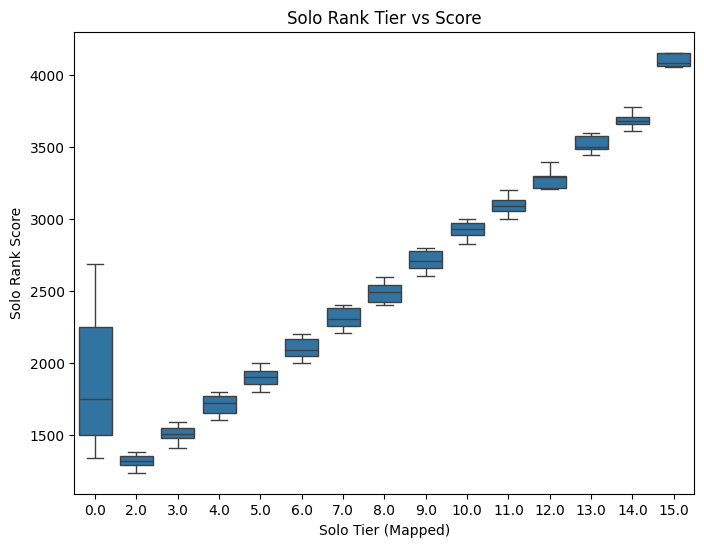

In [493]:
tier_order = [
    'UNRANK', 'BRONZE II', 'SILVER I', 'SILVER II', 'SILVER III',
    'GOLD I', 'GOLD II', 'GOLD III',
    'MASTER I', 'MASTER II', 'MASTER III',
    'GRAND MASTER I', 'GRAND MASTER II', 'GRAND MASTER III',
    'LEGEND', 'HIGH RANKER'
]

# 딕셔너리로 매핑
tier_mapping = {tier: i for i, tier in enumerate(tier_order)}

df['solo_rank_tier_num'] = df['solo_rank_match_tier'].map(tier_mapping)

# 상관계수
print(df[['solo_rank_tier_num', 'solo_rank_match_score']].corr())

# 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='solo_rank_tier_num', y='solo_rank_match_score')
plt.title('Solo Rank Tier vs Score')
plt.xlabel('Solo Tier (Mapped)')
plt.ylabel('Solo Rank Score')
plt.show()


                        party_rank_tier_num  party_rank_match_score
party_rank_tier_num                1.000000                0.827858
party_rank_match_score             0.827858                1.000000


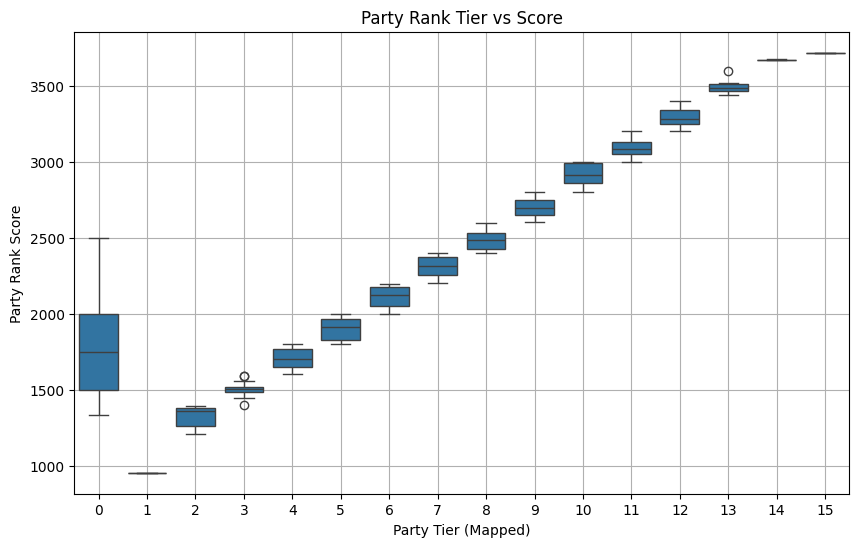

In [494]:
df['party_rank_tier_num'] = df['party_rank_match_tier'].map(tier_mapping)

# 상관계수
print(df[['party_rank_tier_num', 'party_rank_match_score']].corr())

plt.figure(figsize=(10,6))
sns.boxplot(x='party_rank_tier_num', y='party_rank_match_score', data=df)
plt.title("Party Rank Tier vs Score")
plt.xlabel("Party Tier (Mapped)")
plt.ylabel("Party Rank Score")
plt.grid(True)
plt.show()


- 상관관계와 plot으로 확인한 결과 솔로랭크와 파티랭크 모두 **<span style="color:orange">선형적으로 1:1 대응 관계</span>** 를 보이므로 tier 컬럼은 삭제해도 무방

In [495]:
# 컬럼 제거

df = df.drop(['is_win','is_draw','is_loss','solo_rank_match_tier','party_rank_match_tier','solo_rank_tier_num','party_rank_tier_num','clan_flag'], axis=1)

In [496]:
df.columns

Index(['ouid', 'user_kill', 'user_death', 'user_assist', 'total_matches',
       'actual_win_rate', 'user_kda', 'kill_per_match', 'death_per_match',
       'assist_per_match', 'grade_ranking', 'season_grade_ranking',
       'recent_win_rate', 'recent_kill_death_rate', 'recent_assault_rate',
       'recent_sniper_rate', 'recent_special_rate', 'solo_rank_match_score',
       'party_rank_match_score', 'manner_score', 'target'],
      dtype='object')

#### 분석 목표 (클랜전 승률이 높은 유저 파악)

- 식별값인 ouid 제거 후 feature split을 통해 진행

In [497]:
# model library

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [498]:
df_model = df.drop(['ouid'], axis=1)

# input, target split
X = df_model.drop('target', axis=1)
y = df_model['target']

In [499]:
# train, test data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [500]:
# model training

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,  # depth를 줄여서 과적합 방지
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, min_samples_leaf=5, random_state=42)

In [501]:
# model evaluation

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        75

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145

Confusion Matrix:
[[70  0]
 [ 0 75]]


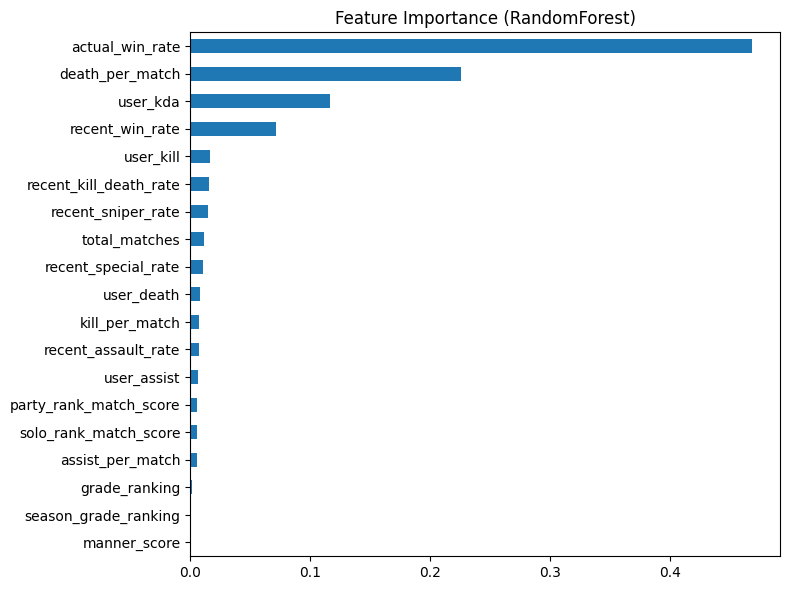

In [502]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importance (RandomForest)")
plt.tight_layout()
plt.show()

In [503]:
from sklearn.metrics import f1_score, accuracy_score

# 학습 데이터 예측
y_train_pred = model.predict(X_train)
print("Train Accuracy:", f1_score(y_train, y_train_pred))

# 테스트 데이터 예측
y_test_pred = model.predict(X_test)
print("Test Accuracy:", f1_score(y_test, y_test_pred))

Train Accuracy: 1.0
Test Accuracy: 1.0


- **<span style="color:orange">actual_win_rate</span>** 가 분석 목표에 너무 직접적인 영향을 끼침..
    - 인지하고 제거했어야했는데..
    - 따라서 해당 모델은 과적합을 일으키는것이 분명함
    - 제거 후 다시 실행

In [504]:
X.drop('actual_win_rate',axis=1, inplace=True)

In [505]:
# 다시 train, test data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.84      0.80        70
           1       0.84      0.76      0.80        75

    accuracy                           0.80       145
   macro avg       0.80      0.80      0.80       145
weighted avg       0.80      0.80      0.80       145

Confusion Matrix:
[[59 11]
 [18 57]]


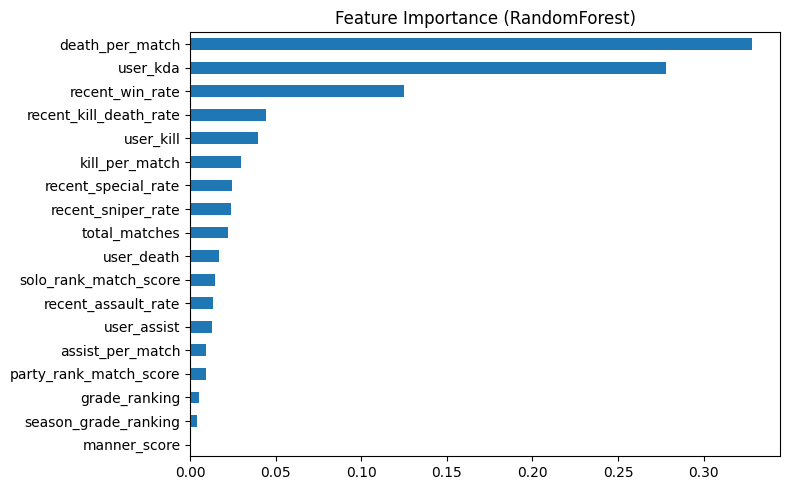

In [506]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 5))
plt.title("Feature Importance (RandomForest)")
plt.tight_layout()
plt.show()

- 이전보단 모델의 성능이 일반화 된거 같긴 한데, 여전히 과적합이 아닌가 하는 의심을 해봐야함
    - Train data와 Test data를 통해 예측을 수행하고 해당 성능의 차이가 **<span style="color:orange">0.1 이상 차이날 경우 과적합을 의심해야함</span>**

In [507]:
# 학습 데이터 예측
y_train_pred = model.predict(X_train)
print("Train Accuracy:", f1_score(y_train, y_train_pred))

# 테스트 데이터 예측
y_test_pred = model.predict(X_test)
print("Test Accuracy:", f1_score(y_test, y_test_pred))

Train Accuracy: 0.8526863084922011
Test Accuracy: 0.7972027972027973


- 제거 후 과적합이 아닌것은 확인 되었고 성능도 제법 준수하게 나옴
    - 또한, feature importnace를 확인해 보면 **<span style="color:orange"> manner_score </span>** 얘는 그냥 필요 없어 보임 > **<span style="color:orange"> 제거 </span>**

- 이제 모델 튜닝을 통해 성능을 조금더 올리는 방향으로 접근

In [508]:
# import library

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

In [509]:
X.drop('manner_score', axis=1, inplace=True)

In [510]:
# 다시 train, test data split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [511]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


In [512]:
# K-Fold 정의 5개로
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 모델은 그대로 random forest
rf = RandomForestClassifier(random_state=42)

# GridSearchCV 정의
scorer = make_scorer(f1_score)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=cv, 
                           scoring=scorer, n_jobs=-1, verbose=2)

# 모델 학습
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 150, 200]},
             scoring=make_scorer(f1_score), verbose=2)

In [513]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [514]:
# 예측
y_pred = best_model.predict(X_test)

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8068965517241379
F1 Score: 0.8082191780821917

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81        70
           1       0.83      0.79      0.81        75

    accuracy                           0.81       145
   macro avg       0.81      0.81      0.81       145
weighted avg       0.81      0.81      0.81       145


Confusion Matrix:
 [[58 12]
 [16 59]]


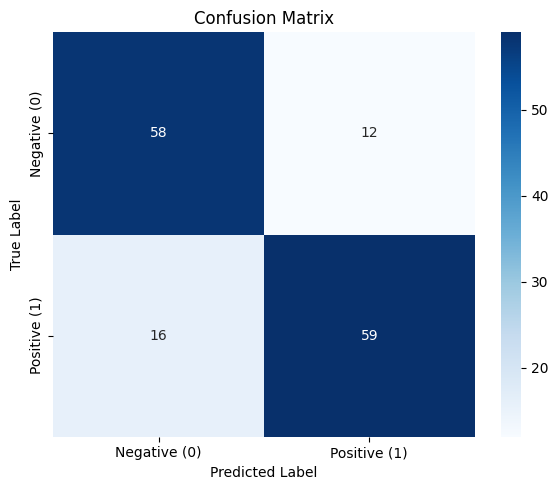

In [515]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Negative (0)', 'Positive (1)']

# 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_25676\1583877449.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Pastel1')


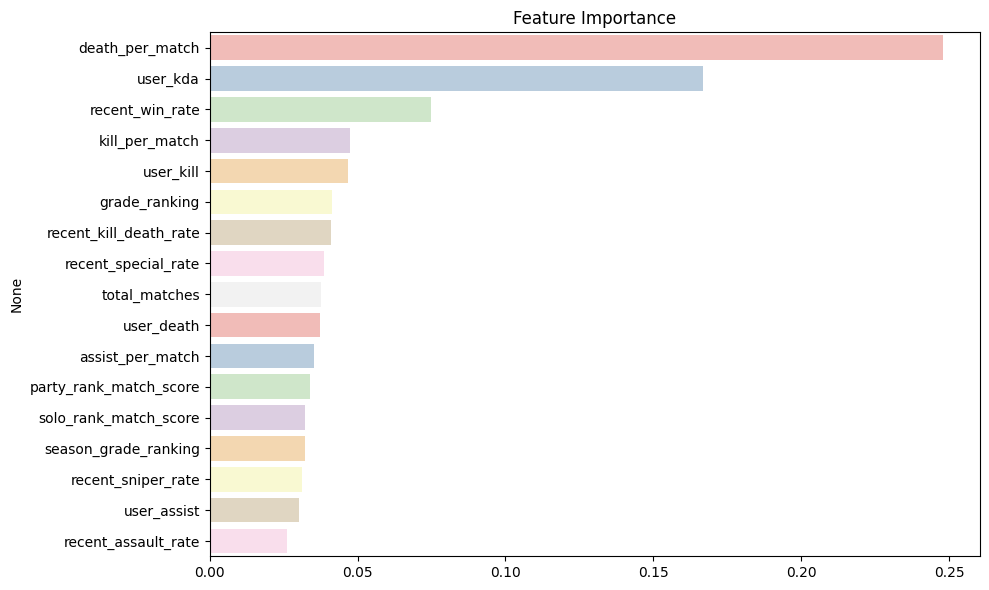

In [516]:
# 특성 중요도 시각화
importances = best_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='Pastel1')
plt.title("Feature Importance")
plt.tight_layout()
plt.show()
